In [ ]:
%pip install numpy
%pip install imageio
%pip install pygraphviz
%pip install matplotlib
%pip install networkx
%pip install tqdm
%pip install pandas

# Introdução à Inteligência Artificial

## Problema das N-rainhas

### Visão geral do problema

O problema das *n-rainhas* consiste em posicionar *n* rainhas em um tabuleiro de tamanho *n x n* de modo que nenhuma rainha ameace a outra.

O caso das 8 rainhas em um tabuleiro de tamanho 8 x 8 é um caso especial do problema mais geral, existindo 92 soluções possíveis.

Apesar de classicamente se buscar por todas as soluções possíveis para cada conjunto de *n* rainhas e tabuleiro *n x n*, na implementação abaixo o objetivo é encontrar a primeira solução e exibi-la, de modo que seja possível avaliar qual o melhor algoritmo de busca a ser utilizado para encontrar a solução de maneira mais rápida. 

Cabe destacar ainda que, os algoritmos utilizados foram apenas o de busca em largura (*Breadth First Search - BFS*) e o de profundidade (*Depth First Search - DFS*), para *n's = 4, 5, 6 e 8*. 

Foi tentado utilizar *n = 16*, porém houve estouro de memória para a *BFS*, se tornando inviável encontrar uma solução para esse tipo de busca, pois, apesar do problema das *n-rainhas* gerar uma árvore considerada profunda, a árvore tem uma característica peculiar, tendo um fator de ramificação que começa em *N* e diminui a cada nível, tornando o topo da árvore **muito largo**, mas com a base estreita. 

Isso posto, como a *BFS* usa uma *FIFO - Fist in, first out* a largura da árvore no topo aumenta consideravelmente para *n's >= 16*, mesmo que a quantidade de nós-filhos a cada nível seja menor do que a quantidade de nós do nível superior, por naturalmente já ser larga se torna praticamente impossivel de encontrar uma solução utilizando uma máquina com pouca memória e, mais ainda, utilizando código em python de forma não otimizada para o tamanho do problema abordado.

### Informações do computador

* Processadores: 8 × AMD Ryzen 7 7800X3D 8-Core Processor
* Memória: 32 GiB de RAM (30,5 GiB utilizável)

In [2]:
from collections import deque
import time
import pandas as pd
import pygraphviz
import imageio
import numpy as np 
import matplotlib.pyplot as plt
import networkx as nx
from tqdm import tqdm

### Tabuleiro

A implementação da classe `QueensBoardChess` foi feita baseada/inspirada no código C disponibilizado no seguinte repositório: [Sabrina Venceslau - ITP_2](https://github.com/BlackbirdBlina/ITP_2/blob/main/nrainhas.c) do qual ao encontrar uma solução a imprime no terminal, indicando a disposição das rainhas no tabuleiro. 

Destaco que algumas das funções do código original foram descartadas por não serem significantes para o propósito do atual, que consiste em utilizar os algoritmos de busca (*BFS e DFS*) para encontrar as soluções possiveis para cada *n* indicado no input. Nesse sentido, apenas os métodos `position_queen` e `valid_position` foram suficientes para dar início ao desenvolvimento da resolução desse problema.

In [3]:
class QueensBoardChess:

    def __init__(self, size_board: int):
        self.n = size_board
        self.board = np.zeros((self.n, self.n))
    
    def position_queen(self, row: int, column: int) -> bool:
        if 0 <= row < self.n and 0 <= column < self.n:
            self.board[row][column] = 1
            return True
        else:
            return False

    def valid_position(self, row: int, column: int) -> bool:
        for i in range(row):
            if self.board[i][column] == 1:
                return False

        i, j = row, column
        while i >= 0 and j >= 0:
            if self.board[i][j] == 1:
                return False
            i -= 1
            j -= 1

        k, y = row, column
        while k >= 0 and y < self.n:
            if self.board[k][y] == 1:
                return False
            k -= 1
            y += 1

        return True

### Construção da árvore - Classe Problem

A classe `Problem` foi implementada com base no código Python disponibilizado no link a seguir: [Prof. Dr. Tibério Pereira - Tópico 2/Célula 5](https://colab.research.google.com/drive/1D3434-OnhrBQ3q-cSW0Sksle-BvDhTHP).

Diante disso, se faz necessário especificar do que se trata o problema, a partir das seguintes características:

* **Estado inicial:** Tabuleiro vazio, sem nenhuma "rainha" posicionada. 
* **Possíveis ações:** Inicialmente o agente poderá posicionar a primeira peça no espaço total *n x n* do tabuleiro, todavia, a cada iteração o espaço total diminui em 1. Além disso, um conjunto de espaços, a princípio disponíveis, ficam impossibilitados de colocar uma segunda peça, pois esta poderia ser atacada por uma rainha já posicionada no tabuleiro.

    Vale salientar que, segundo Russel & Norvig (2010), o problema das *n-rainhas* é um tipo de *constraint satisfaction problem* ou simplesmente *CSP*, ou seja, sua resolução é dada levando em consideração um conjunto de restrições e essas restrições são definidas segundo uma formalização matemática, abaixo *simplificada*:

    Seja *E* o conjunto dos espaços a serem preenchidos com uma peça (rainha) no tabuleiro e *k* a quantidade de ações realizadas, então sua cardinalidade inicial, com k = 1, será de *|E<sub>1</sub>| = n²*.

    Assim, a cada ação realizada é necessário remover do conjunto de espaços disponíveis, todos os espaços que não poderiam ser ocupados, além do próprio espaço da peça já posicionada, ou seja:

    *E<sub>k+1</sub> = E<sub>k</sub> \ A(P<sub>k</sub>)*

    Sendo *A* o conjunto dos pares ordenados que representam os espaços conflitantes e *P<sub>k</sub>* o conjunto da posição da rainha no tabuleiro, bem como todas as casas que ela pode atacar.

    Para mais detalhes, ler *Artificial Intelligence: A Modern Approach (Russell & Norvig) — capítulo 6.5*

* **Modelo de transição**: Para cada peça posicionada um novo estado é gerado, levando em consideração a ação tomada e a atualização de um novo estado. Nesse sentido, teremos o método `transition_fn` retornando `state + (col,)`, que concatena as tuplas referentes às colunas em que a peça foi colocada. Ex.: Se n = 4, então state = (0, 3) logo teremos (0, 3) + (1,) = (0, 3, 1) e segue até posicionar as 4 peças.

* **Espaço de estados:** São todos os A(P<sub>k</sub>) dados a cada ação, pois a partir disso será possível decidi qual o melhor espaço para posicionar uma nova peça até finalizar a quantidade *n* de peças a serem postas no tabuleiro.

* **Teste de meta:** No contexto de **resolução de problemas por meio de busca** os *agentes* são agentes *baseados em meta* ([PEREIRA, 2026](https://colab.research.google.com/drive/1vY71ichst5vBo7pvJeXZgKDzv8Jf3R4D)). Nesse sentido, para o problema das *n-rainhas* foi definido que a meta é atingida quando encontra a primeira solução, ou seja, ao atingir o *n* indicado. Assim, ocorre quando a quantidade de peças já postas no tabuleiro é igual ao número *n* dado no input. Com isso, nesse problema não há uma comparação direta entre um estado ideal e os estados que estão sendo gerados, havendo apenas uma comparação se o estado em questão já atingiu o *n* dado, ou seja, o tamanho do tabuleiro: `len(state) == self.board_chess.n`.

* **Função de custo do caminho:** Para o problema das *n-rainhas* o custo do caminho foi considerado 1, pois levou em consideração apenas a ação de por uma peça no tabuleiro, porém, pode ter sido uma decisão ingênua a depender de como se pode enxergar a complexidade do problema abordado.


In [4]:
class Problem:

    def __init__(self, initial_state, actions, transition_model, goal_test, step_cost):

        self.initial_state = initial_state
        self.actions = actions                    
        self.transition_model = transition_model  
        self.goal_test = goal_test                
        self.step_cost = step_cost  

class Node:

    def __init__(self, problem, parent = None, action = None):

        self.parent = parent
        self.action = action

        if parent is None:
            self.state = problem.initial_state
            self.path_cost = 0.0
        else:
            self.state = problem.transition_model(parent.state, action)
            self.path_cost = parent.path_cost + problem.step_cost(parent.state, action)


    def __eq__(self, other):

        return isinstance(other, Node) and self.state == other.state

    def __hash__(self):

        return hash(self.state)

### Definição do problema das n-rainhas - Classe QueensProblem

Sendo construído a partir da herança da classe `Problem`. Como ensinado no [material](https://colab.research.google.com/drive/1D3434-OnhrBQ3q-cSW0Sksle-BvDhTHP#scrollTo=d94de0fe-db7c-4d95-895e-37bdb4ecbc25) disponibilizado pelo Prof. Dr. Tibério Pereira. A classe `QueensProblem` estabelece:
- Ações possíveis `actions_fn`;
- Modelo de transição `transition_fn`;
- Teste de meta `goal_test_fn`;
- Custo de passo `step_cost_fn`. *Não utilizado*

In [5]:
class QueensProblem(Problem):

    def __init__(self, start_node, size_board: int):

        self.board_chess = QueensBoardChess(size_board)

        super().__init__(initial_state = start_node,
                         actions = self.actions_fn,
                         transition_model = self.transition_fn,
                         goal_test = self.goal_test_fn,
                         step_cost = self.step_cost_fn)

    def actions_fn(self, state):

        actions = []
        current_row = len(state)

        if current_row >= self.board_chess.n:
            return actions

        self.board_chess.board.fill(0)
        for each_row, each_column in enumerate(state):
            self.board_chess.position_queen(each_row, each_column)

        for column in range(self.board_chess.n):
            if self.board_chess.valid_position(current_row, column):
                actions.append((current_row, column))  
        return actions

    def transition_fn(self, state, action):

        row, col = action
        return state + (col,)

    def goal_test_fn(self, state):
            
        return len(state) == self.board_chess.n

    def step_cost_fn(self, state, action, uniform_cost = True):
        return 1

### Construção visual da árvore de estados

O trecho de código abaixo cria um grid que representa cada estado do tabuleiro.

**OBS.:** *Esse trecho foi construído com o auxílio da ferramenta `Gemini`. Mesmo que tenham sido feitos alguns ajustes não somente nesse trecho, como também na função `generate_animation`, a maior parte do código para a animação foi gerada a partir dessa IA*.

Exemplo de visualização para n = 5:

* Busca em Largura (BFS):

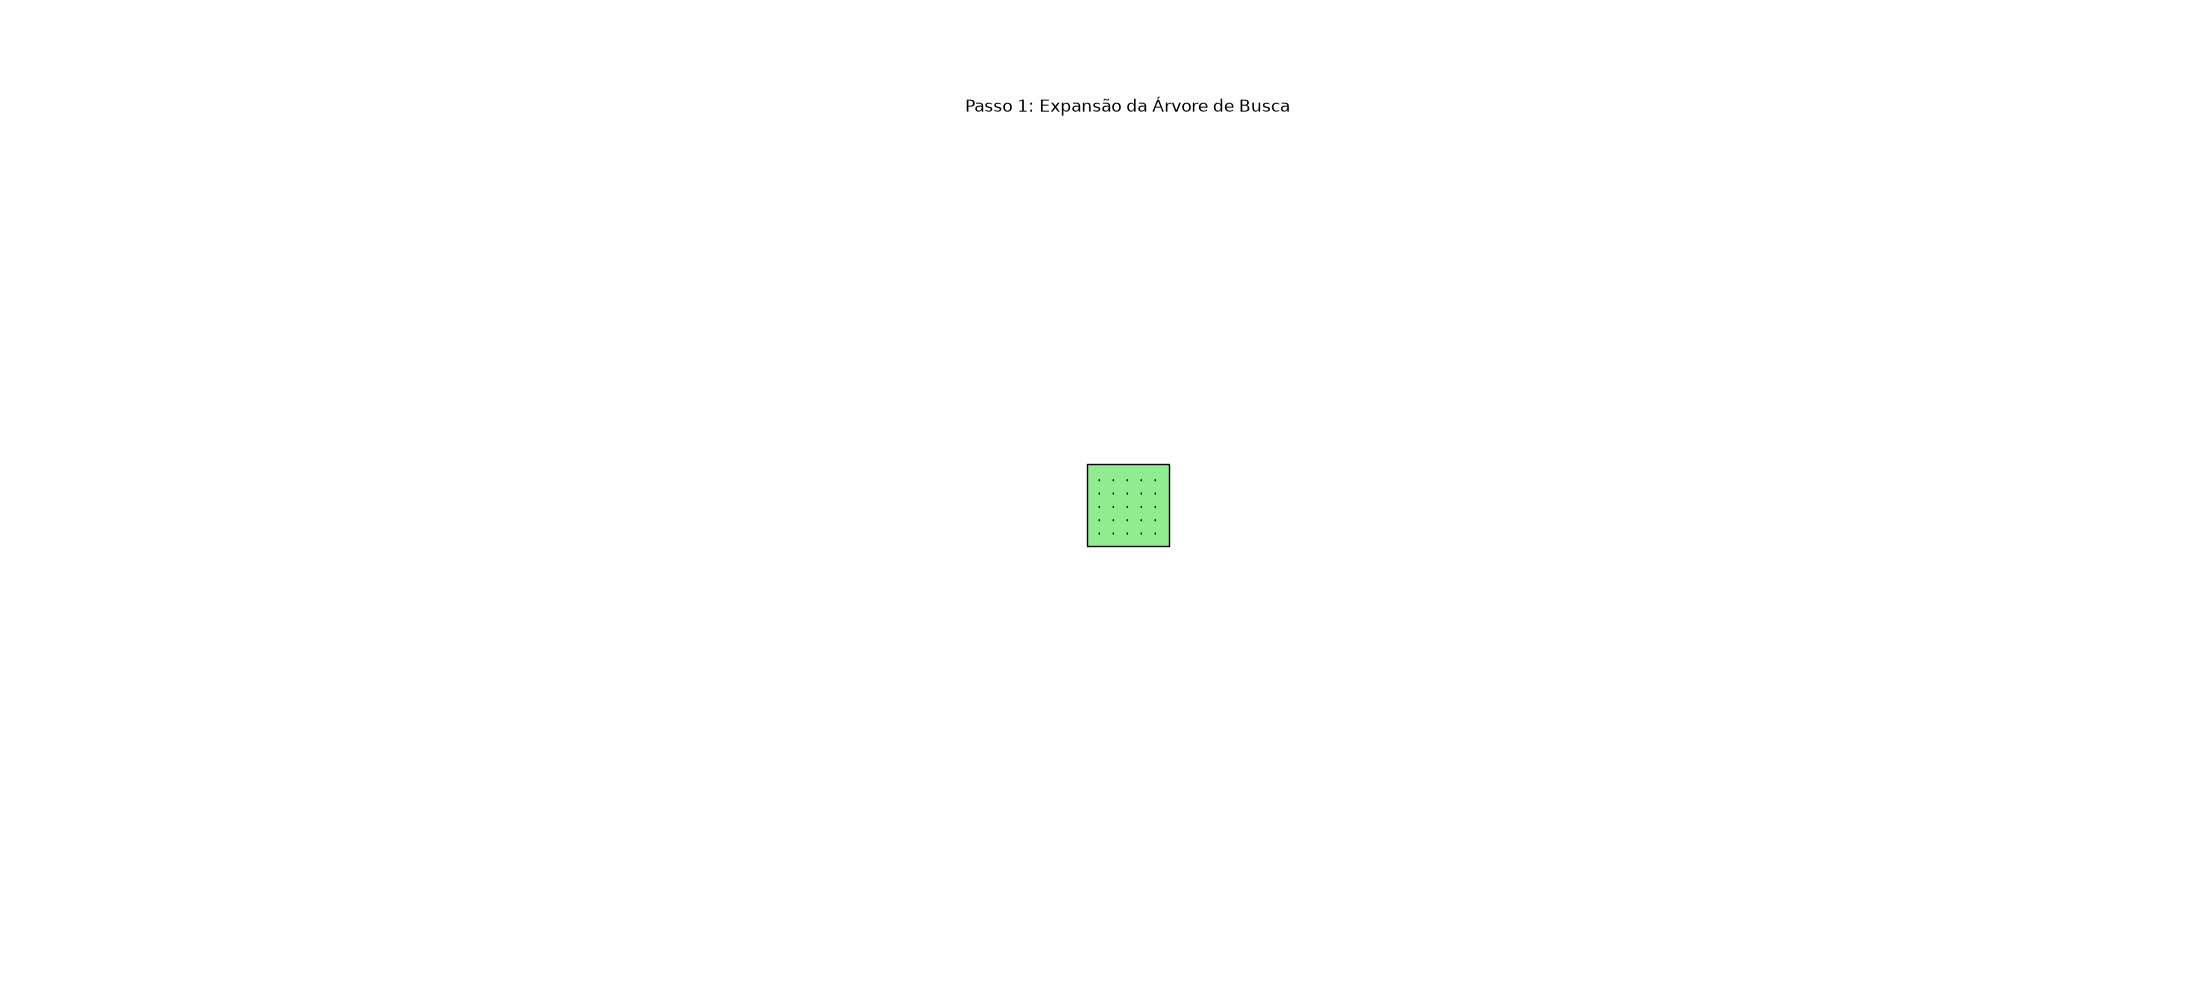

* Busca em Profundidade (DFS):

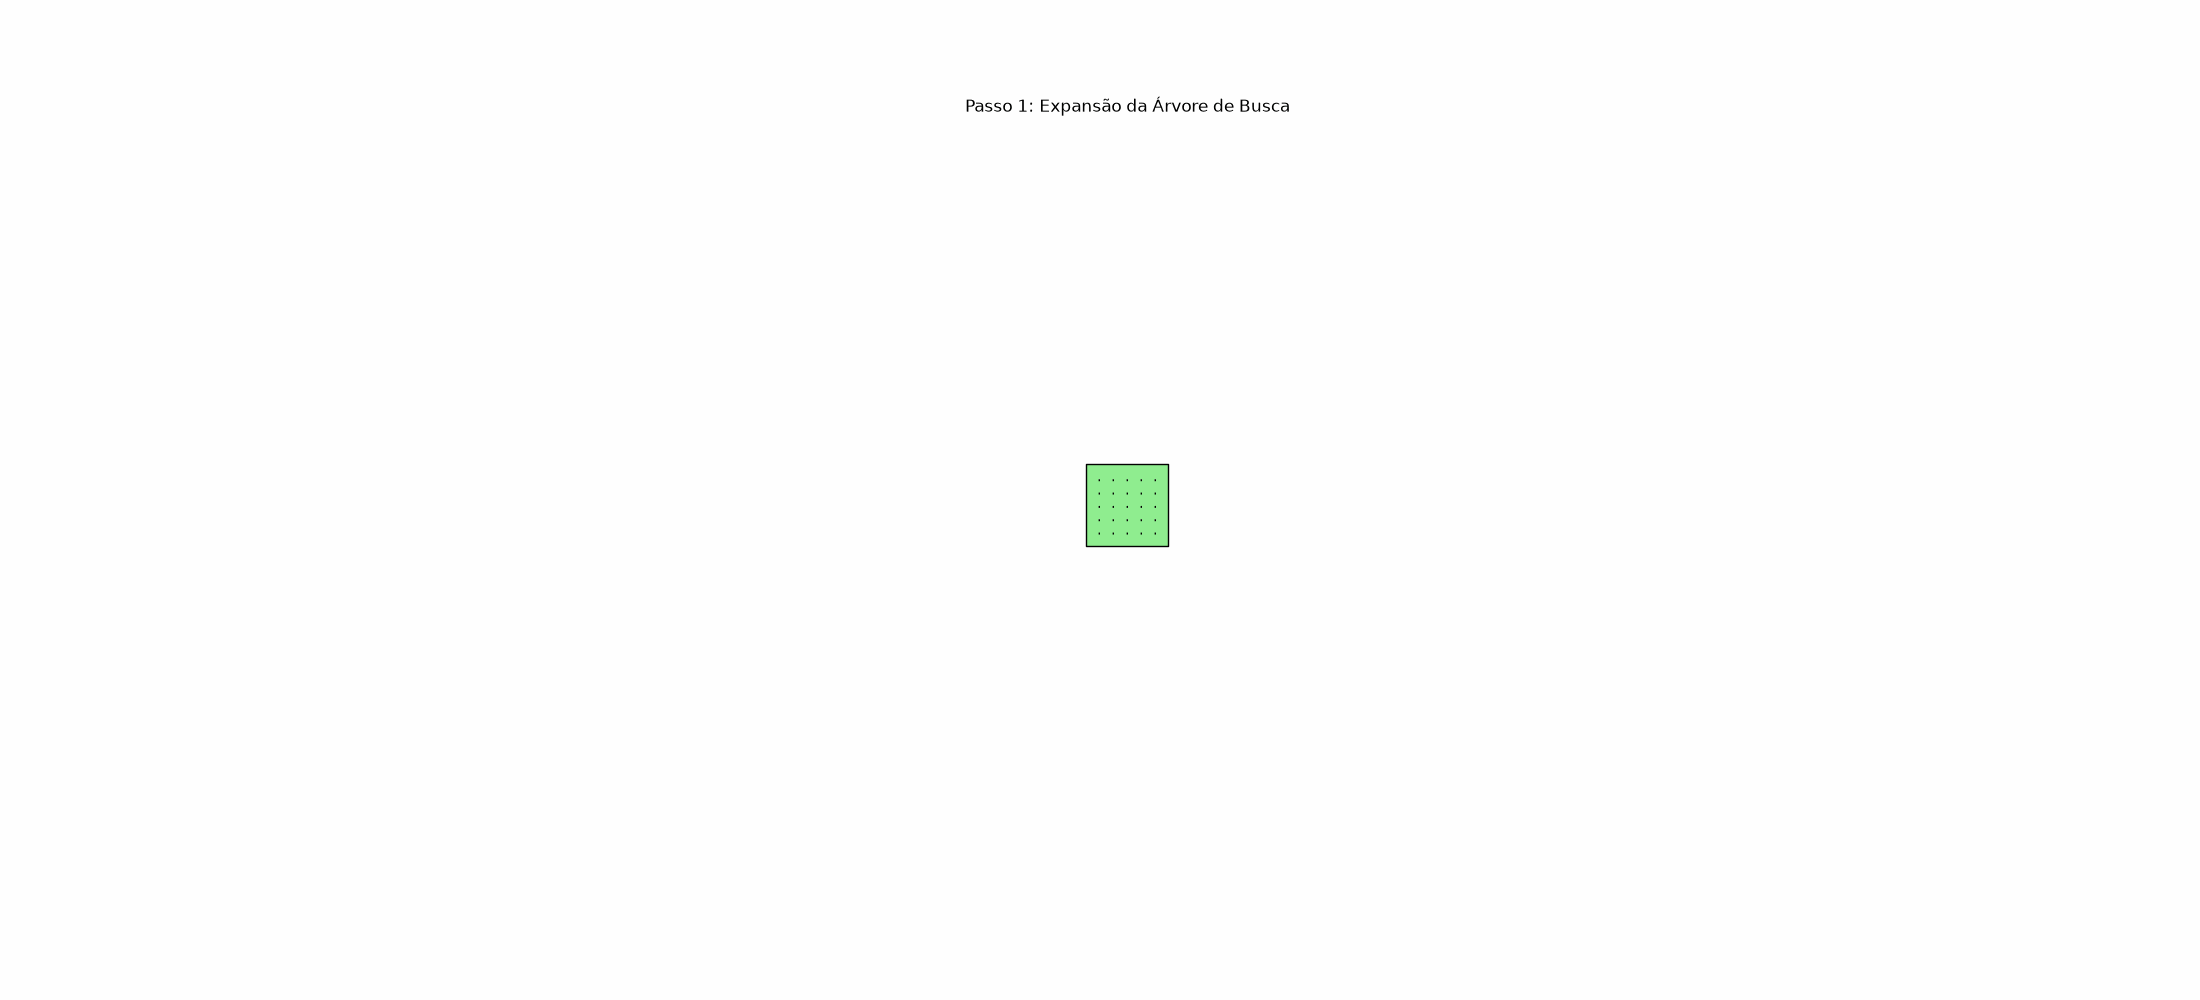

In [6]:
def state_to_board_str(state, n):
    grid = [["." for _ in range(n)] for _ in range(n)]
    for r, c in enumerate(state):
        grid[r][c] = "Q"
    return "\n".join(" ".join(row) for row in grid)

### Busca em largura - Breadth First Search (BFS)

A implementação do algoritmo de busca BFS foi feita também a partir do [material](https://colab.research.google.com/drive/1D3434-OnhrBQ3q-cSW0Sksle-BvDhTHP#scrollTo=d94de0fe-db7c-4d95-895e-37bdb4ecbc25) disponibilizado para estudo, com os ajustes necessários de modo que reflete o problema das *n-rainhas*, bem como possbilita gerar a animação e a tabela de tempos.

Vale salientar que, como o objetivo é realizar uma comparação entre os algoritmos de busca utilizados, a biblioteca `time` do `python` também foi utilizada para capturar o tempo gasto em cada busca.

Destaca-se ainda que, o `return` no método `seach`, também foi modificado para retornar um dicionário que permite gerar uma tabela para melhor visualizar as informações obtidas, vide `resultado_rainhas.csv`.

In [7]:
class BreadthFirstSearch:

    def __init__(self, problem):

        self.problem = problem
        self.frontier = deque()  
        self.explored = set()    
        self.tree_graph = nx.DiGraph()
        self.history = []

    def search(self):

        start_time = time.perf_counter()
        root = Node(problem = self.problem)
        n = self.problem.board_chess.n

        board_label = state_to_board_str(root.state, n)
        self.tree_graph.add_node(id(root), state = str(root.state), label = board_label)

        self.frontier.append(root)

        solution_node = None
        node_count = 0

        with tqdm(desc = "Executando BFS", unit = "º nó") as pbar:
            while self.frontier:
                node = self.frontier.popleft()
                node_count += 1
                self.explored.add(node)

                active_nodes = list(self.tree_graph.nodes())
                self.history.append((active_nodes, id(node)))

                if self.problem.goal_test(node.state):
                    solution_node = node
                    pbar.update(1)
                    break

                for action in self.problem.actions(node.state):

                    child = Node(self.problem, node, action)
                    child_label = state_to_board_str(child.state, n)
                    self.tree_graph.add_node(id(child), state = str(child.state), label = child_label)
                    self.tree_graph.add_edge(id(node), id(child))

                    if (child not in self.explored) and (child not in self.frontier):
                        self.frontier.append(child)

                pbar.set_postfix(Explored = f": {len(self.explored)}", Frontier = f": {len(self.frontier)}")
                pbar.update(1)

        end_time = time.perf_counter()

        return {
            "Algoritmo": "BFS",
            "N (Board)": n,
            "Solução": solution_node.state if solution_node else None,
            "Nós explorados/nó da solução": len(self.explored),
            "Nós na Fronteira": len(self.frontier),
            "Tempo (ms)": round((end_time - start_time) * 1000, 4)
        }

### Busca em profundidade - Depth First Search (DFS)

Semelhante à situação da BFS, o algoritmo de busca em profundidade (DFS) também se baseia no [material](https://colab.research.google.com/drive/1vY71ichst5vBo7pvJeXZgKDzv8Jf3R4D) disponibilizado na disciplina de Introdução à IA, porém com alguns ajustes.

Dito isso, cabe destacar que a DFS é um algoritmo que se difere da BFS principalmente por utilizar uma heurística diferente, levando a uma melhor performance na busca de uma solução, pois usa *LIFO - Last In, First Out* em sua estrutura base.

In [8]:
class DepthFirstSearch:

    def __init__(self, problem):
        self.problem = problem
        self.frontier = []
        self.explored = set()
        self.tree_graph = nx.DiGraph()
        self.history = []

    def search(self):
        start_time = time.perf_counter()
        root = Node(problem = self.problem)
        n = self.problem.board_chess.n

        board_label = state_to_board_str(root.state, n)
        self.tree_graph.add_node(id(root), state = str(root.state), label = board_label)

        self.frontier.append(root)
        solution_node = None
        node_count = 0

        with tqdm(desc = "Executando DFS", unit = "º nó") as pbar:
            while self.frontier:
                node = self.frontier.pop()

                if node in self.explored:
                    continue

                node_count += 1
                self.explored.add(node)

                active_nodes = list(self.tree_graph.nodes())
                self.history.append((active_nodes, id(node)))

                if self.problem.goal_test(node.state):
                    solution_node = node
                    pbar.update(1)
                    break

                for action in reversed(list(self.problem.actions(node.state))):

                    child = Node(self.problem, node, action)
                    child_label = state_to_board_str(child.state, n)
                    self.tree_graph.add_node(id(child), state = str(child.state), label = child_label)
                    self.tree_graph.add_edge(id(node), id(child))

                    if (child not in self.explored) and (child not in self.frontier):
                        self.frontier.append(child)

                pbar.set_postfix(Explored = f": {len(self.explored)}", Frontier = f": {len(self.frontier)}")
                pbar.update(1)

        end_time = time.perf_counter()

        return {
            "Algoritmo": "DFS",
            "N (Board)": n,
            "Solução": solution_node.state if solution_node else None,
            "Nós explorados/nó da solução": len(self.explored),
            "Nós na Fronteira": len(self.frontier),
            "Tempo (ms)": round((end_time - start_time) * 1000, 4)
        }

### Animação

A princípio tentei criar uma animação que fosse representativa de todos os estados, porém à medida em que o *n* cresce, a árvore cresce consideravelmente, tornando-se inviável uma visualização da árvore de estados a partir de *n = 6*.

Todavia, é possível ter uma visualização mínima do comportamento e dos estados para cada tipo de busca com n's menores.

In [9]:
def generate_animation(graph, steps, filename = "n_queens_search.gif"):
    frames = []

    pos = nx.drawing.nx_agraph.graphviz_layout(graph, prog = "dot")
    fig, ax = plt.subplots(figsize = (22, 10))

    for step, (active_nodes, current_node) in tqdm(list(enumerate(steps))):
        ax.clear()
        subgraph = graph.subgraph(active_nodes)

        node_colors = [
            "lightgreen" if n == current_node else "white" 
            for n in subgraph.nodes()
        ]

        labels = {n: graph.nodes[n]["label"] for n in subgraph.nodes()}

        nx.draw(
            subgraph,
            pos,
            labels = labels,
            node_color = node_colors,
            node_shape = "s",        
            node_size = 3500,      
            font_size = 8,
            font_family = "monospace", 
            edgecolors = "black",   
            arrowsize = 12,
            ax = ax,
        )
        ax.set_title(f"Passo {step + 1}: Expansão da Árvore de Busca", fontsize = 12)

        fig.canvas.draw()
        image = imageio.core.util.Array(
            np.array(fig.canvas.buffer_rgba())
        )

        frames.append(image)

    plt.close()
    
    imageio.mimsave(filename, frames, fps = 1) 



### Input - Animação

O input criado a seguir tem como objetivo gerar especialmente a animação, apesar de também mostrar o tempo gasto em em cada busca, esse input é melhor para gerar a animação.

Não recomendo usar um *n > 5*, apesar de conseguir gerar a árvore para *n = 6* é impossível de ver cada estado do tabuleiro, pois o tamanho da tela acaba se tornando pequena e, nesse sentido, cada representação do tabuleiro acaba ficando por cima de outra representação de um *nó* anterior. Assim, a partir de *n = 6* não é recomendado tentar gerar essa visualização, a menos que se tenha um monitor muito grande e uma capacidade de memória muito boa, então basta alterar a variável `figsize` para o tamanho que se adeque à máquina utilizada.

In [10]:
problem_instance = QueensProblem(start_node = (), size_board = 5)

print("Breadth-First Search (BFS):")

bfs = BreadthFirstSearch(problem_instance)
result1 = bfs.search()

if result1:
    print("Solução encontrada (colunas por linha):", result1["Solução"])
print("Nós explorados (BFS):", len(bfs.explored))
generate_animation(bfs.tree_graph, bfs.history, filename = "n_queens_bfs1.gif")

print("\nDepth-First Search (DFS):")

dfs = DepthFirstSearch(problem_instance)
result2 = dfs.search()

if result2:
    print("Solução DFS (colunas por linha):", result2["Solução"])
print("Nós explorados (DFS):", len(dfs.explored))
generate_animation(dfs.tree_graph, dfs.history, filename = "n_queens_dfs2.gif")

Breadth-First Search (BFS):


Executando BFS: 45º nó [00:00, 3900.55º nó/s, Explored=: 44, Frontier=: 10]
Fontconfig warning: "/usr/share/fontconfig/conf.avail/05-reset-dirs-sample.conf", line 6: unknown element "reset-dirs"


Solução encontrada (colunas por linha): (0, 2, 4, 1, 3)
Nós explorados (BFS): 45


100%|██████████| 45/45 [00:07<00:00,  6.28it/s]



Depth-First Search (DFS):


Executando DFS: 6º nó [00:00, 4301.85º nó/s, Explored=: 5, Frontier=: 7]


Solução DFS (colunas por linha): (0, 2, 4, 1, 3)
Nós explorados (DFS): 6


100%|██████████| 6/6 [00:00<00:00, 21.75it/s]


### Input - Comparativo

Abaixo é onde, de fato, pode se extrair as informações que viabiliza uma comparação mais clara entre os algoritmos.

Apesar de ser uma amostra pequena, é notável que a DFS possui uma performance muito melhor em relação a BFS.

### Resultados

#### BFS

* n = 4 \
    Solução encontrada em 16 passos \
    Tempo gasto: 4.5650ms

* n = 5 \
    Solução encontrada em 45 passos \
    Tempo gasto: 12.0983ms

* n = 6 \
    Solução encontrada em 150 passos \
    Tempo gasto: 33.6625ms

* n = 8 \
    Solução encontrada em 1966 passos \
    Tempo gasto: 623.7645ms

* n = 16 \
    Solução não encontrada (OOM - Out of Memory) 34837 passos  \
    Tempo gasto: 31:54s 
#### DFS

* n = 4 \
    Solução encontrada em 9 passos \
    Tempo gasto: 3.5562ms

* n = 5 \
    Solução encontrada em 6 passos \
    Tempo gasto: 2.4499ms

* n = 6 \
    Solução encontrada em 32 passos \
    Tempo gasto: 6.5022ms

* n = 8 \
    Solução encontrada em 114 passos \
    Tempo gasto: 27.7565ms

* n = 16 \
    Solução encontrada em 10053 passos \
    Tempo gasto: 03s

#### Análise

Com os resultados obtidos podemos concluir que a BFS **não** performa bem em árvores largas.
Além disso, em todos os *n* esse tipo de busca executa mais passos do que a DFS, que se apresentou melhor em todos os *n's" usados.

Não obstante, para fazer uma comparação justa, seria interessante utilizar um problema que gere uma árvore muito profunda e estreita, para analisar qual das buscas é mais performática em termos de tempo gasto para encontrar uma solução. A hipótese levantada, dado os resultados que foram obtidos neste experimento, é que a DFS continue tendo uma melhor performance em comparação à BFS, porém se faz necessário realizar novos testes com um problema que gere uma árvore com as características anteriormente citadas. Pode ser um trabalho futuro.

Isso posto, realizar este exercício foi muito gratificante e enriquecedor, apesar de ser ainda muito básico, é uma ótima atividade que fica aberta a otimizações e instiga para novas investigações.

In [ ]:
board_sizes = [4, 5, 6, 8, 16]
results = []

for size in board_sizes:
    problem_dfs = QueensProblem(start_node = (), size_board = size)
    dfs = DepthFirstSearch(problem_dfs)
    res_dfs = dfs.search()
    results.append(res_dfs)

    problem_bfs = QueensProblem(start_node = (), size_board = size)
    bfs = BreadthFirstSearch(problem_bfs)
    res_bfs = bfs.search()
    results.append(res_bfs)

df = pd.DataFrame(results)

print()
print(df.to_string(index = False))

df['Solução'] = df['Solução'].apply(lambda x: " - ".join(map(str, x)))

nome_arquivo = "resultado_n_rainhas.csv"
df.to_csv(nome_arquivo, index = False, sep = ",", encoding = "utf-8-sig")

print(f"\nTabela salva com sucesso no arquivo: {nome_arquivo}")

Executando DFS: 9º nó [00:00, 3629.34º nó/s, Explored=: 8, Frontier=: 3]
Executando BFS: 16º nó [00:00, 4692.93º nó/s, Explored=: 15, Frontier=: 2]
Executando DFS: 6º nó [00:00, 4560.68º nó/s, Explored=: 5, Frontier=: 7]
Executando BFS: 45º nó [00:00, 4292.85º nó/s, Explored=: 44, Frontier=: 10]
Executando DFS: 32º nó [00:00, 4432.99º nó/s, Explored=: 31, Frontier=: 9]
Executando BFS: 150º nó [00:00, 4607.74º nó/s, Explored=: 149, Frontier=: 4] 
Executando DFS: 114º nó [00:00, 4408.34º nó/s, Explored=: 113, Frontier=: 12]
Executando BFS: 1966º nó [00:00, 3472.27º nó/s, Explored=: 1965, Frontier=: 92] 
Executando DFS: 10053º nó [00:03, 2724.68º nó/s, Explored=: 10052, Frontier=: 61]
Executando BFS: 34837º nó [30:54,  9.18º nó/s, Explored=: 34837, Frontier=: 203821]